In [1]:
import pandas as pd
import geopandas as gpd

INPUT_CSV = 'csv_input/07312340_modified_shapefile.csv'

df = pd.read_csv(INPUT_CSV)

In [2]:
cross_map = df.groupby('County')['Constituency'].unique()
inconsistent = cross_map[cross_map.apply(len) > 1]

if inconsistent.empty:
    print("Every County maps to exactly one Constituency.")
else:
    print("Counties spanning multiple Constituencies:\n")
    for county, constituencies in inconsistent.items():
        print(f"  {county}: {list(constituencies)}")

ward_map = df.groupby(['District', 'District_Ward'])['Constituency'].unique()
ward_inconsistent = ward_map[ward_map.apply(len) > 1]

if ward_inconsistent.empty:
    print("Every District_Ward maps to exactly one Constituency.")
else:
    print("Wards spanning multiple Constituencies:\n")
    for (district, ward), constituencies in ward_inconsistent.items():
        print(f"  {district} / {ward}: {list(constituencies)}")
        subset = df[(df['District'] == district) & (df['District_Ward'] == ward)]
        for _, row in subset.iterrows():
            print(f"      Shape_ID={row['Shape_ID']}  Constituency={row['Constituency']}")
        print()

import numpy as np

def population_quota(population):
    if population <= 400_000:
        return 20000
    elif population <= 650_000:
        return 23000
    elif population <= 1_000_000:
        return 24000
    else:
        return 25000

district_pop = df.groupby('District')['Population'].sum()

district_rows = []
for district, total_pop in district_pop.items():
    quota = population_quota(total_pop)
    seats = int(np.ceil(total_pop / quota))
    new_quota = total_pop / seats
    district_rows.append({
        'District': district,
        'Total_Population': total_pop,
        'Quota': quota,
        'Seats': seats,
        'New_Quota': new_quota,
        'Range_Low': 0.8 * new_quota,
        'Range_High': 1.2 * new_quota,
    })

district_summary = pd.DataFrame(district_rows).set_index('District')

ward_pop = df.groupby(['District', 'District_Ward'])['Population'].sum()

violations = []
for (district, ward), pop in ward_pop.items():
    low = district_summary.loc[district, 'Range_Low']
    high = district_summary.loc[district, 'Range_High']
    if not (low <= pop <= high):
        violations.append((district, ward, pop, low, high))

if not violations:
    print("All wards fall within the acceptable population range (0.8x-1.2x new quota).")
else:
    print("Wards outside the acceptable population range:\n")
    for district, ward, pop, low, high in violations:
        print(f"  {district} / {ward}: population={pop:.0f}  allowed=[{low:.0f}, {high:.0f}]")

ward_counts = df.groupby('District')['District_Ward'].nunique()

seat_mismatches = []
for district, seats in district_summary['Seats'].items():
    n_wards = ward_counts.get(district, 0)
    if n_wards not in (seats, seats + 1):  # 1 extra ward vs. allocated seats is acceptable
        seat_mismatches.append((district, n_wards, seats))

if not seat_mismatches:
    print("Every district's ward count matches its allocated seats (or is exactly 1 higher).")
else:
    print("Districts where ward count does not match allocated seats:\n")
    for district, n_wards, seats in seat_mismatches:
        print(f"  {district}: wards={n_wards}  seats={seats}")

gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df['geometry']))

# Repair invalid geometries first -- shapely predicates like .touches()/.intersects()
# can silently return wrong results (e.g. False for a real shared edge) on invalid polygons.
fixed_geometry = gdf.geometry.apply(lambda g: g if g.is_valid else g.buffer(0))

EDGE_TOL = 1e-9  # minimum shared-boundary length to count as "a common edge"

def shares_edge(a, b):
    if not a.intersects(b):
        return False
    return a.boundary.intersection(b.boundary).length > EDGE_TOL

def find_components(ids, geoms):
    parent = list(range(len(ids)))

    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i

    def union(i, j):
        pi, pj = find(i), find(j)
        if pi != pj:
            parent[pi] = pj

    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            if shares_edge(geoms[i], geoms[j]):
                union(i, j)

    components = {}
    for i in range(len(ids)):
        components.setdefault(find(i), []).append(ids[i])
    return list(components.values())

disconnected_wards = []
for (district, ward), group in gdf.groupby(['District', 'District_Ward']):
    if len(group) <= 1:
        continue
    geoms = fixed_geometry.loc[group.index].tolist()
    components = find_components(group['Shape_ID'].tolist(), geoms)
    if len(components) > 1:
        disconnected_wards.append((district, ward, components))

if not disconnected_wards:
    print("Every ward's polygons all share a common edge with at least one other polygon in the same ward.")
else:
    print("Wards with disconnected polygon groups:\n")
    for district, ward, components in disconnected_wards:
        print(f"  {district} / {ward}:")
        for comp in components:
            print(f"      {comp}")
        print()

Every County maps to exactly one Constituency.
Every District_Ward maps to exactly one Constituency.
All wards fall within the acceptable population range (0.8x-1.2x new quota).
Every district's ward count matches its allocated seats (or is exactly 1 higher).
Every ward's polygons all share a common edge with at least one other polygon in the same ward.


In [3]:
def broad_region(region):
    if region in ('Alma Valley East', 'Alma Valley West'):
        return 'Capital'
    elif region == 'Highland':
        return 'Highland'
    else:
        return 'Lowland'

df_polygon = df[['County', 'District', 'Shape_ID', 'geometry', 'Area', 'Region',
                  'County_Type', 'Population', 'District_Ward', 'Constituency']].copy()
df_polygon['Region'] = df_polygon['Region'].apply(broad_region)

_geom = gpd.GeoSeries.from_wkt(df_polygon['geometry'])
df_polygon['centroid'] = _geom.centroid.apply(lambda p: (p.x, p.y))

df_polygon.head()

,County,District,Shape_ID,geometry,Area,Region,County_Type,Population,District_Ward,Constituency,centroid
0,A01,Alington City,A01_001,"POLYGON ((2883.27 1328.07, 2878.63 1333.14, 28...",0.577635,Capital,E1,10428,Ward 35,The City of Alington,"(2879.0834004432318, 1327.760509303106)"
1,A01,Alington City,A01_002,"POLYGON ((2866.75 1312, 2864.7 1312.61, 2866.4...",1.008987,Capital,A1,10036,Ward 37,The City of Alington,"(2876.5348861310513, 1313.6566745910743)"
2,A01,Alington City,A01_003,"POLYGON ((2876.55 1317.07, 2879.48 1318.86, 28...",0.416791,Capital,F1,6029,Ward 36,The City of Alington,"(2877.4554621151638, 1320.111755190619)"
3,A01,Alington City,A01_004,"POLYGON ((2869.47 1318.22, 2869.13 1316.06, 28...",0.386001,Capital,D1,7069,Ward 36,The City of Alington,"(2872.6532667631704, 1317.3815797694542)"
4,A01,Alington City,A01_005,"POLYGON ((2878.04 1323.18, 2875.08 1326.19, 28...",0.327799,Capital,E1,5768,Ward 35,The City of Alington,"(2874.375253808555, 1323.444032598566)"


In [4]:
from shapely.ops import unary_union

county_records = []
for county, group in df.groupby('County'):
    geoms = gpd.GeoSeries.from_wkt(group['geometry'])
    fixed = geoms.apply(lambda g: g if g.is_valid else g.buffer(0))
    merged_geom = unary_union(fixed.tolist())

    county_records.append({
        'Zone': group['Zone'].iloc[0],
        'County': county,
        'District': group['District'].iloc[0],
        'geometry': merged_geom,
        'Area': group['Area'].sum(),
        'Region': broad_region(group['Region'].iloc[0]),
        'Population': group['Population'].sum(),
        'Constituency': group['Constituency'].iloc[0],
        'centroid': (merged_geom.centroid.x, merged_geom.centroid.y),
    })

df_county = pd.DataFrame(county_records)


district_records = []
for (district, ward), group in df_polygon.groupby(['District', 'District_Ward']):
    geoms = gpd.GeoSeries.from_wkt(group['geometry'])
    fixed = geoms.apply(lambda g: g if g.is_valid else g.buffer(0))
    merged_geom = unary_union(fixed.tolist())

    district_records.append({
        'District': district,
        'District_Ward': ward,
        'geometry': merged_geom,
        'Area': group['Area'].sum(),
        'Region': group['Region'].iloc[0],
        'Population': group['Population'].sum(),
        'Constituency': group['Constituency'].iloc[0],
        'centroid_point': merged_geom.centroid,
    })

df_districts = pd.DataFrame(district_records)

# District_ID: rank each ward by how close its centroid is to the overall
# District's centroid (union of all its wards) -- 1 = closest, i.e. the district center
district_center = (
    df_districts.groupby('District')['geometry']
    .apply(lambda geoms: unary_union(geoms.tolist()).centroid)
)
dist_to_center = df_districts.apply(
    lambda row: row['centroid_point'].distance(district_center[row['District']]), axis=1
)
df_districts['District_ID'] = (
    dist_to_center.groupby(df_districts['District']).rank(method='first').astype(int)
)

df_districts['centroid'] = df_districts['centroid_point'].apply(lambda p: (p.x, p.y))
df_districts = df_districts.drop(columns=['centroid_point'])
df_districts = df_districts[['District', 'District_ID', 'District_Ward', 'geometry', 'Area', 'Region', 'Population', 'Constituency', 'centroid']]

# keep each district's wards ordered by ID (closest to farthest from center)
# District_Ward is kept as the stable join key back to df_polygon/original data --
# District_ID is derived (distance rank) and will change if geometries are regenerated,
# so anything downstream must join on ('District', 'District_Ward'), never on row
# position or District_ID.
df_districts = df_districts.sort_values(['District', 'District_ID']).reset_index(drop=True)

assert not df_districts.duplicated(['District', 'District_Ward']).any(), \
    "('District', 'District_Ward') must uniquely identify each df_districts row -- downstream joins depend on it"

df_districts

,District,District_ID,District_Ward,geometry,Area,Region,Population,Constituency,centroid
0,Alington City,1,Ward 3,"POLYGON ((2864 1334, 2856.88 1334, 2856.88 133...",3.246925,Capital,21474,The City of Alington,"(2858.285335320632, 1344.0501931359797)"
1,Alington City,2,Ward 28,"POLYGON ((2864 1339.34, 2864 1346.52, 2872.69 ...",1.773416,Capital,26816,The City of Alington,"(2872.057949889211, 1343.6000356396187)"
2,Alington City,3,Ward 31,"POLYGON ((2875.83 1337.47, 2878.23 1334.94, 28...",1.661607,Capital,22180,The City of Alington,"(2871.4754643040105, 1334.9550576492163)"
3,Alington City,4,Ward 25,"POLYGON ((2874.34 1350.79, 2873.89 1351.95, 28...",1.628542,Capital,22310,The City of Alington,"(2870.4082686796046, 1350.5380067564768)"
4,Alington City,5,Ward 32,"POLYGON ((2863.83 1322.69, 2859.83 1324.15, 28...",1.594000,Capital,22786,The City of Alington,"(2868.076396870934, 1327.6668213045316)"
...,...,...,...,...,...,...,...,...,...
1774,White Bridge and Red Market,64,Ward 28,"POLYGON ((3139.79 1185.21, 3140.17 1185.92, 31...",2.831111,Lowland,24938,Red Market,"(3142.9662486014327, 1190.807762347438)"
1775,White Bridge and Red Market,65,Ward 45,"POLYGON ((2962.39 1206.73, 2961.03 1207.57, 29...",2.258161,Lowland,24773,White Bridge,"(2966.0783076368807, 1208.8330122185278)"
1776,White Bridge and Red Market,66,Ward 31,"POLYGON ((3145.53 1156.59, 3144.73 1157.11, 31...",4.909123,Lowland,24824,Red Market,"(3144.9078342615603, 1170.3591659680253)"
1777,White Bridge and Red Market,67,Ward 64,"POLYGON ((2961.68 1183.25, 2961.42 1181.93, 29...",2.838780,Lowland,24544,White Bridge,"(2959.10093494857, 1189.6536775790014)"


In [5]:
constituency_records = []
for constituency, group in df_polygon.groupby('Constituency'):
    geoms = gpd.GeoSeries.from_wkt(group['geometry'])
    fixed = geoms.apply(lambda g: g if g.is_valid else g.buffer(0))
    merged_geom = unary_union(fixed.tolist())

    constituency_records.append({
        'Constituency': constituency,
        'geometry': merged_geom,
        'Area': group['Area'].sum(),
        'Region': group['Region'].iloc[0],
        'Population': group['Population'].sum(),
        'centroid': (merged_geom.centroid.x, merged_geom.centroid.y),
    })

df_constituency = pd.DataFrame(constituency_records).reset_index()

In [6]:
zone_records = []
for zone, group in df.groupby('Zone'):
    geoms = gpd.GeoSeries.from_wkt(group['geometry'])
    fixed = geoms.apply(lambda g: g if g.is_valid else g.buffer(0))
    merged_geom = unary_union(fixed.tolist())

    zone_records.append({
        'Authority': zone,
        'geometry': merged_geom,
        'Area': group['Area'].sum(),
        'Population': group['Population'].sum(),
        'centroid': (merged_geom.centroid.x, merged_geom.centroid.y),
    })

df_zone = pd.DataFrame(zone_records)
df_zone

,Authority,geometry,Area,Population,centroid
0,Alington,"POLYGON ((2754 1250.61, 2754 1268, 2754 1277.1...",364.492568,3390148,"(2840.1061388851313, 1304.1323685699845)"
1,Alma Bridge,"POLYGON ((2754 1099.42, 2754 1121.82, 2754 112...",1189.670155,6001884,"(3030.519298832011, 1121.8123808187402)"
2,Alma Forest,"POLYGON ((2404 410, 2404 542, 2404 608, 2404 6...",5492.699954,278131,"(2761.4437059870816, 680.3990531246079)"
3,Alma Heath,"POLYGON ((2404 1136, 2404 1214, 2446 1214, 249...",2086.036032,84655,"(2572.7175732217574, 1021.3640167364017)"
4,Alma Junction,"POLYGON ((2677 824, 2677 850.86, 2677 884.96, ...",374.441115,722369,"(2754.000000000001, 816.0000000000002)"
5,Aqua Bay,"POLYGON ((1273 1110.8, 1273 1117.62, 1273 1125...",6065.483069,210248,"(1528.7902158998052, 1262.954607592725)"
6,Bayes Valley,"POLYGON ((3084 763.04, 3084 814, 3084 842.87, ...",1966.051320,435823,"(3283.5936484279623, 711.4452680312663)"
7,Central,"POLYGON ((2908 1347.52, 2908 1353.08, 2908 135...",422.443556,2146182,"(3024.285714285714, 1374.8571428571424)"
8,Clifton Wick,"POLYGON ((3235 916.6649, 3235 926.0522, 3235 9...",1200.247500,529692,"(3412.710705381259, 921.3306150010386)"
9,Cotham Heights,"POLYGON ((3235 1319.6001, 3235 1322.5104, 3235...",670.011439,1418409,"(3344.9912998976442, 1298.7369498464684)"


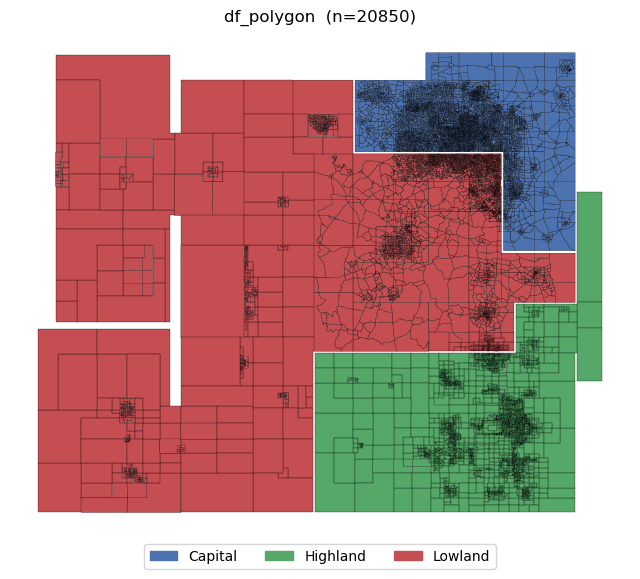

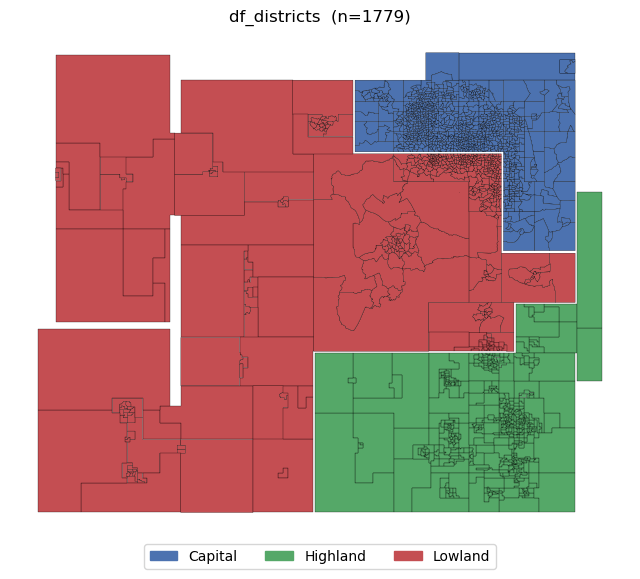

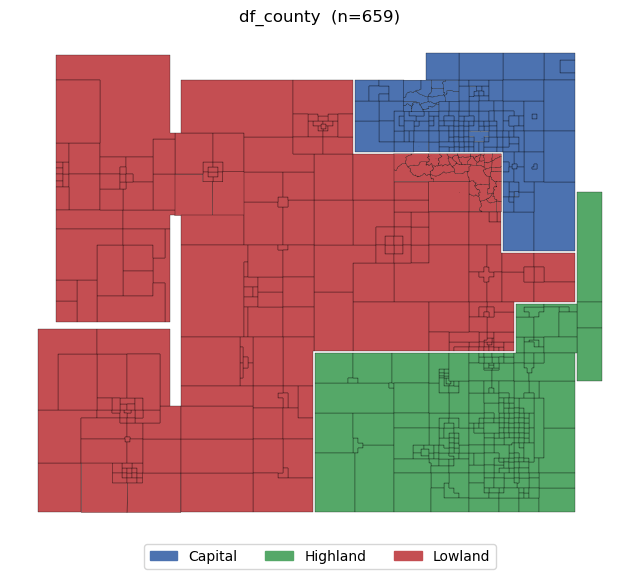

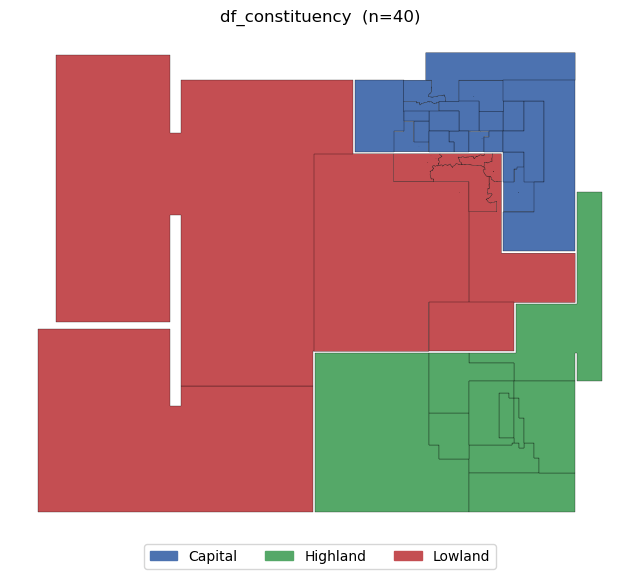

In [7]:
import matplotlib.pyplot as plt

REGION_COLORS = {'Capital': '#4C72B0', 'Highland': '#55A868', 'Lowland': '#C44E52'}

def to_gdf(source_df):
    first_geom = source_df['geometry'].iloc[0]
    if isinstance(first_geom, str):
        geometry = gpd.GeoSeries.from_wkt(source_df['geometry'])
    else:
        geometry = gpd.GeoSeries(source_df['geometry'].values)
    return gpd.GeoDataFrame(source_df, geometry=geometry)

datasets = [
    ('df_polygon', df_polygon),
    ('df_districts', df_districts),
    ('df_county', df_county),
    ('df_constituency', df_constituency),
]

for name, data in datasets:
    gdf_plot = to_gdf(data)
    colors = gdf_plot['Region'].map(REGION_COLORS)

    fig, ax = plt.subplots(figsize=(8, 8))
    gdf_plot.plot(ax=ax, color=colors, edgecolor='black', linewidth=0.2)
    ax.set_title(f"{name}  (n={len(gdf_plot)})")
    ax.set_aspect('equal')
    ax.set_axis_off()
    ax.legend(
        handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in REGION_COLORS.values()],
        labels=list(REGION_COLORS.keys()),
        loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08)
    )
    plt.show()

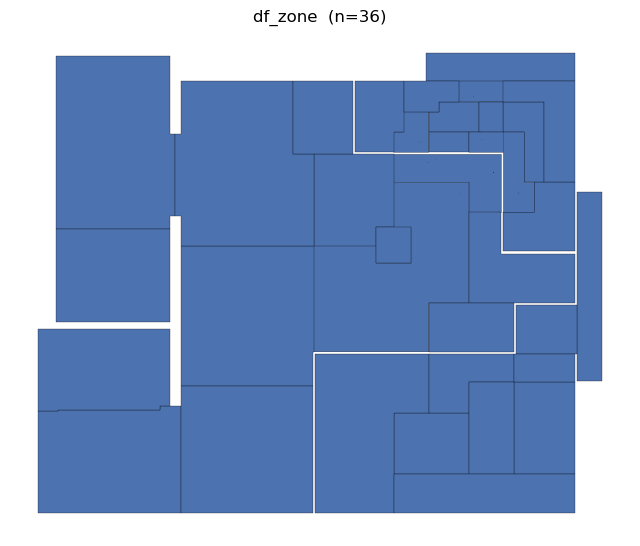

In [8]:
gdf_zone = to_gdf(df_zone)

fig, ax = plt.subplots(figsize=(8, 8))
gdf_zone.plot(ax=ax, color='#4C72B0', edgecolor='black', linewidth=0.2)
ax.set_title(f"df_zone  (n={len(gdf_zone)})")
ax.set_aspect('equal')
ax.set_axis_off()
plt.show()

In [9]:
import os

os.makedirs('csv_output', exist_ok=True)

def export_csv(source_df, filename):
    export_df = source_df.copy()
    first_geom = export_df['geometry'].iloc[0]
    if not isinstance(first_geom, str):
        export_df['geometry'] = export_df['geometry'].apply(lambda g: g.wkt)
    export_df.to_csv(f'csv_output/{filename}', index=False)

export_csv(df_polygon, 'df_polygon.csv')
export_csv(df_districts, 'df_districts.csv')
export_csv(df_county, 'df_county.csv')
export_csv(df_constituency, 'df_constituency.csv')
export_csv(df_zone, 'authority.csv')

print("Exported df_polygon, df_districts, df_county, df_constituency, df_zone to csv_output/")

Exported df_polygon, df_districts, df_county, df_constituency, df_zone to csv_output/
